In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import sys
sys.path.append('../src') 

from model import TerrainGenerator
from config import LATENT_DIM, TILE_SIZE

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Testing on: {device}")

generator = TerrainGenerator(LATENT_DIM).to(device)

weights_path = '../models/generator2.pth'
state_dict = torch.load(weights_path, map_location=device)

generator.load_state_dict(state_dict)
generator.eval()
print("Weights loaded successfully!")

Testing on: cuda
Weights loaded successfully!


In [20]:
def generate_simple_terrain_grid(generator, rows, cols, latent_dim, tile_size, overlap_width, device, blending=True):
    """
    Generates and stitches a 2D grid of terrain tiles using an unconditional GAN.
    """
    # Calculate the total dimensions of the final stitched canvas
    total_h = tile_size + (rows - 1) * (tile_size - overlap_width)
    total_w = tile_size + (cols - 1) * (tile_size - overlap_width)
    
    # Initialize an empty canvas
    canvas = torch.zeros(1, 3, total_h, total_w, device=device)
    
    # Pre-compute gradients if blending is enabled
    if blending:
        alpha_y = torch.linspace(0.0, 1.0, overlap_width, device=device).view(1, 1, overlap_width, 1)
        alpha_x = torch.linspace(0.0, 1.0, overlap_width, device=device).view(1, 1, 1, overlap_width)

    for r in range(rows):
        for c in range(cols):
            y_start = r * (tile_size - overlap_width)
            y_end = y_start + tile_size
            x_start = c * (tile_size - overlap_width)
            x_end = x_start + tile_size
            
            # 1. Generate the new tile unconditionally (only noise)
            noise = torch.randn(1, latent_dim, 1, 1, device=device)
            with torch.no_grad():
                new_tile = generator(noise)
            
            # 2. Setup the weight map for overlapping
            W = torch.ones(1, 1, tile_size, tile_size, device=device)
            
            # Overlap on Top Edge
            if r > 0:
                if blending:
                    W[:, :, :overlap_width, :] = torch.min(W[:, :, :overlap_width, :], alpha_y)
                else:
                    W[:, :, :overlap_width, :] = 0.0 
                
            # Overlap on Left Edge
            if c > 0:
                if blending:
                    W[:, :, :, :overlap_width] = torch.min(W[:, :, :, :overlap_width], alpha_x)
                else:
                    W[:, :, :, :overlap_width] = 0.0

            # 3. Blend and apply to canvas
            canvas_patch = canvas[:, :, y_start:y_end, x_start:x_end]
            blended = (1.0 - W) * canvas_patch + W * new_tile
            canvas[:, :, y_start:y_end, x_start:x_end] = blended

    return canvas.squeeze().cpu().numpy()

# --- Execution ---

# Define the overlap you want since there is no CONDITION_WIDTH variable
OVERLAP_WIDTH = 16 

terrain_map = generate_simple_terrain_grid(
    generator=generator, 
    rows=9, 
    cols=9, 
    latent_dim=LATENT_DIM, 
    tile_size=TILE_SIZE, 
    overlap_width=OVERLAP_WIDTH, 
    device=device,
    blending=False
)

print(f"Generated stitched terrain shape: {terrain_map.shape}")
print(f"Elevation Min: {terrain_map[0].min():.2f}, Max: {terrain_map[0].max():.2f}")

Generated stitched terrain shape: (3, 2176, 2176)
Elevation Min: 0.00, Max: 0.61


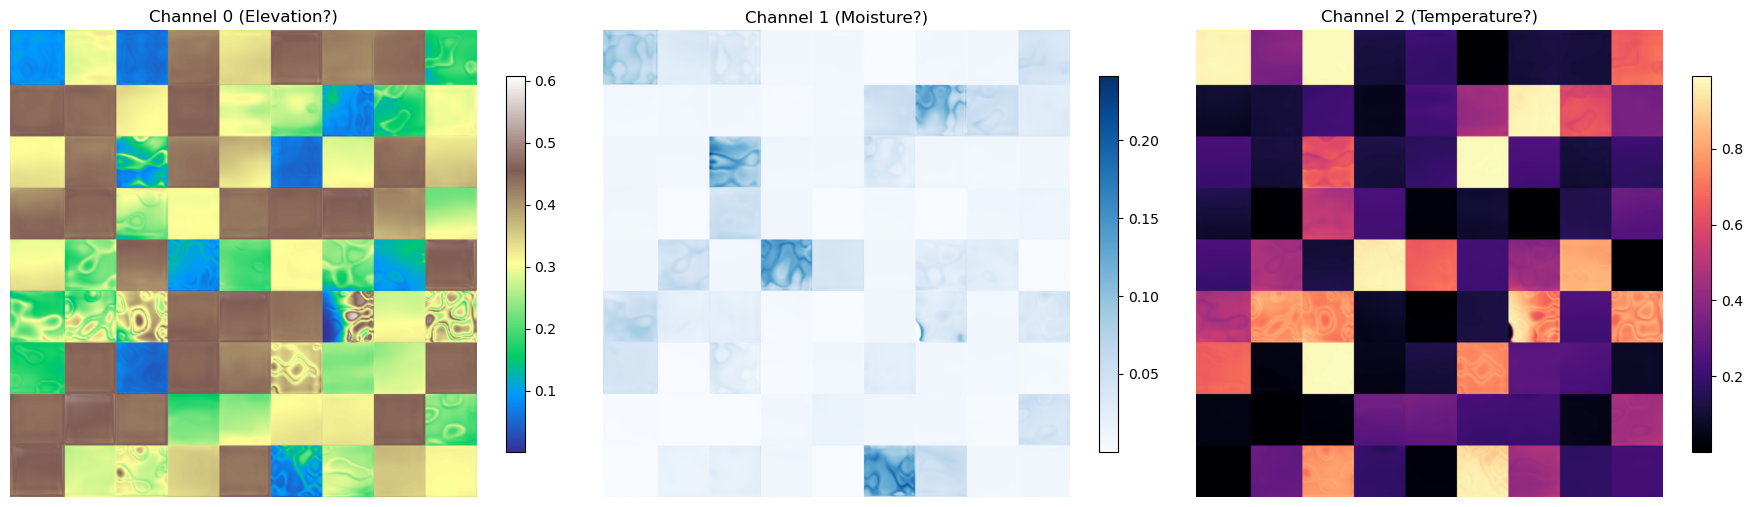

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(terrain_map[0], cmap='terrain')
axes[0].set_title("Channel 0 (Elevation?)")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(terrain_map[1], cmap='Blues')
axes[1].set_title("Channel 1 (Moisture?)")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(terrain_map[2], cmap='magma')
axes[2].set_title("Channel 2 (Temperature?)")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
import pyvista as pv
import numpy as np

pv.set_jupyter_backend('trame') 

elevation = terrain_map[0]

x = np.arange(0, elevation.shape[1], 1)
y = np.arange(0, elevation.shape[0], 1)
x, y = np.meshgrid(x, y)

z_exaggeration = 50.0 
z = elevation * z_exaggeration

grid = pv.StructuredGrid(x, y, z)

grid.point_data["Elevation"] = elevation.flatten(order="F")

plotter = pv.Plotter(window_size=[800, 600])

plotter.add_mesh(
    grid, 
    scalars="Elevation",
    cmap="terrain",
    show_edges=False,
    lighting=True
)

plotter.add_axes()
plotter.set_background('white')

plotter.show()

C:\Users\Orzeł\AppData\Local\Temp\ipykernel_10716\2924208182.py:15: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  grid = pv.StructuredGrid(x, y, z)


Widget(value='<iframe src="http://localhost:59801/index.html?ui=P_0x23cc091d090_4&reconnect=auto" class="pyvis…